In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Made by:
*  Anderson Fonseca Lopez
*  Jhonatan Zamora



# Context

In [ ]:
# Import required libraries
import os
from collections import Counter
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import random
from pylab import rcParams
from wordcloud import WordCloud
from nltk import word_tokenize

# Import scikit-learn components
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier

# Set default figure size for plots
rcParams['figure.figsize'] = (30, 60)

# Enable inline plotting for Jupyter notebooks
%matplotlib inline

# Dataset configuration parameters
records_in_file = 568454  # Total number of records in the original file
sample_size = 5000        # Desired sample size for analysis

# File path to the Amazon reviews dataset
filename = "/content/drive/MyDrive/Anderson Fonseca López/2. Estudio/1. Ingeniería de sistemas y computación/2025 - 1/Big Data/Proyecto 2/Reviews.csv"

# Initialize random number generator for reproducibility
random.seed(101)

# Generate random indices to skip (for creating our sample)
skip = sorted(random.sample(range(1, records_in_file + 1), records_in_file - sample_size))

# Read CSV file while skipping the selected rows to create our sample
amazon_reviews = pd.read_csv(filename, skiprows=skip)

# Display the first few rows of the loaded data
amazon_reviews.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
1,34,B001EO5QW8,A3PMM0NFVEJGK9,"Megan ""Bad at Nicknames""",13,13,4,1166313600,Good Instant,This is a good instant oatmeal from the best o...
2,36,B001EO5QW8,A2CI0RLADCRKPF,T. J. Ryan,3,3,4,1210464000,satisfying,"McCann's Instant Irish Oatmeal, Variety Pack o..."
3,618,B000G6RYNE,ABCXJIXC6Q6EB,Arthur Kang,3,4,5,1194307200,awesome chips,these are the best chips out there.. nothing c...
4,639,B000G6RYNE,A2W1A5GK4A03ZT,"M. Gonzales ""emelgee""",0,0,5,1336262400,GREAT DEAL,I knew my family already liked these chips so ...


Average words per review: 82.37


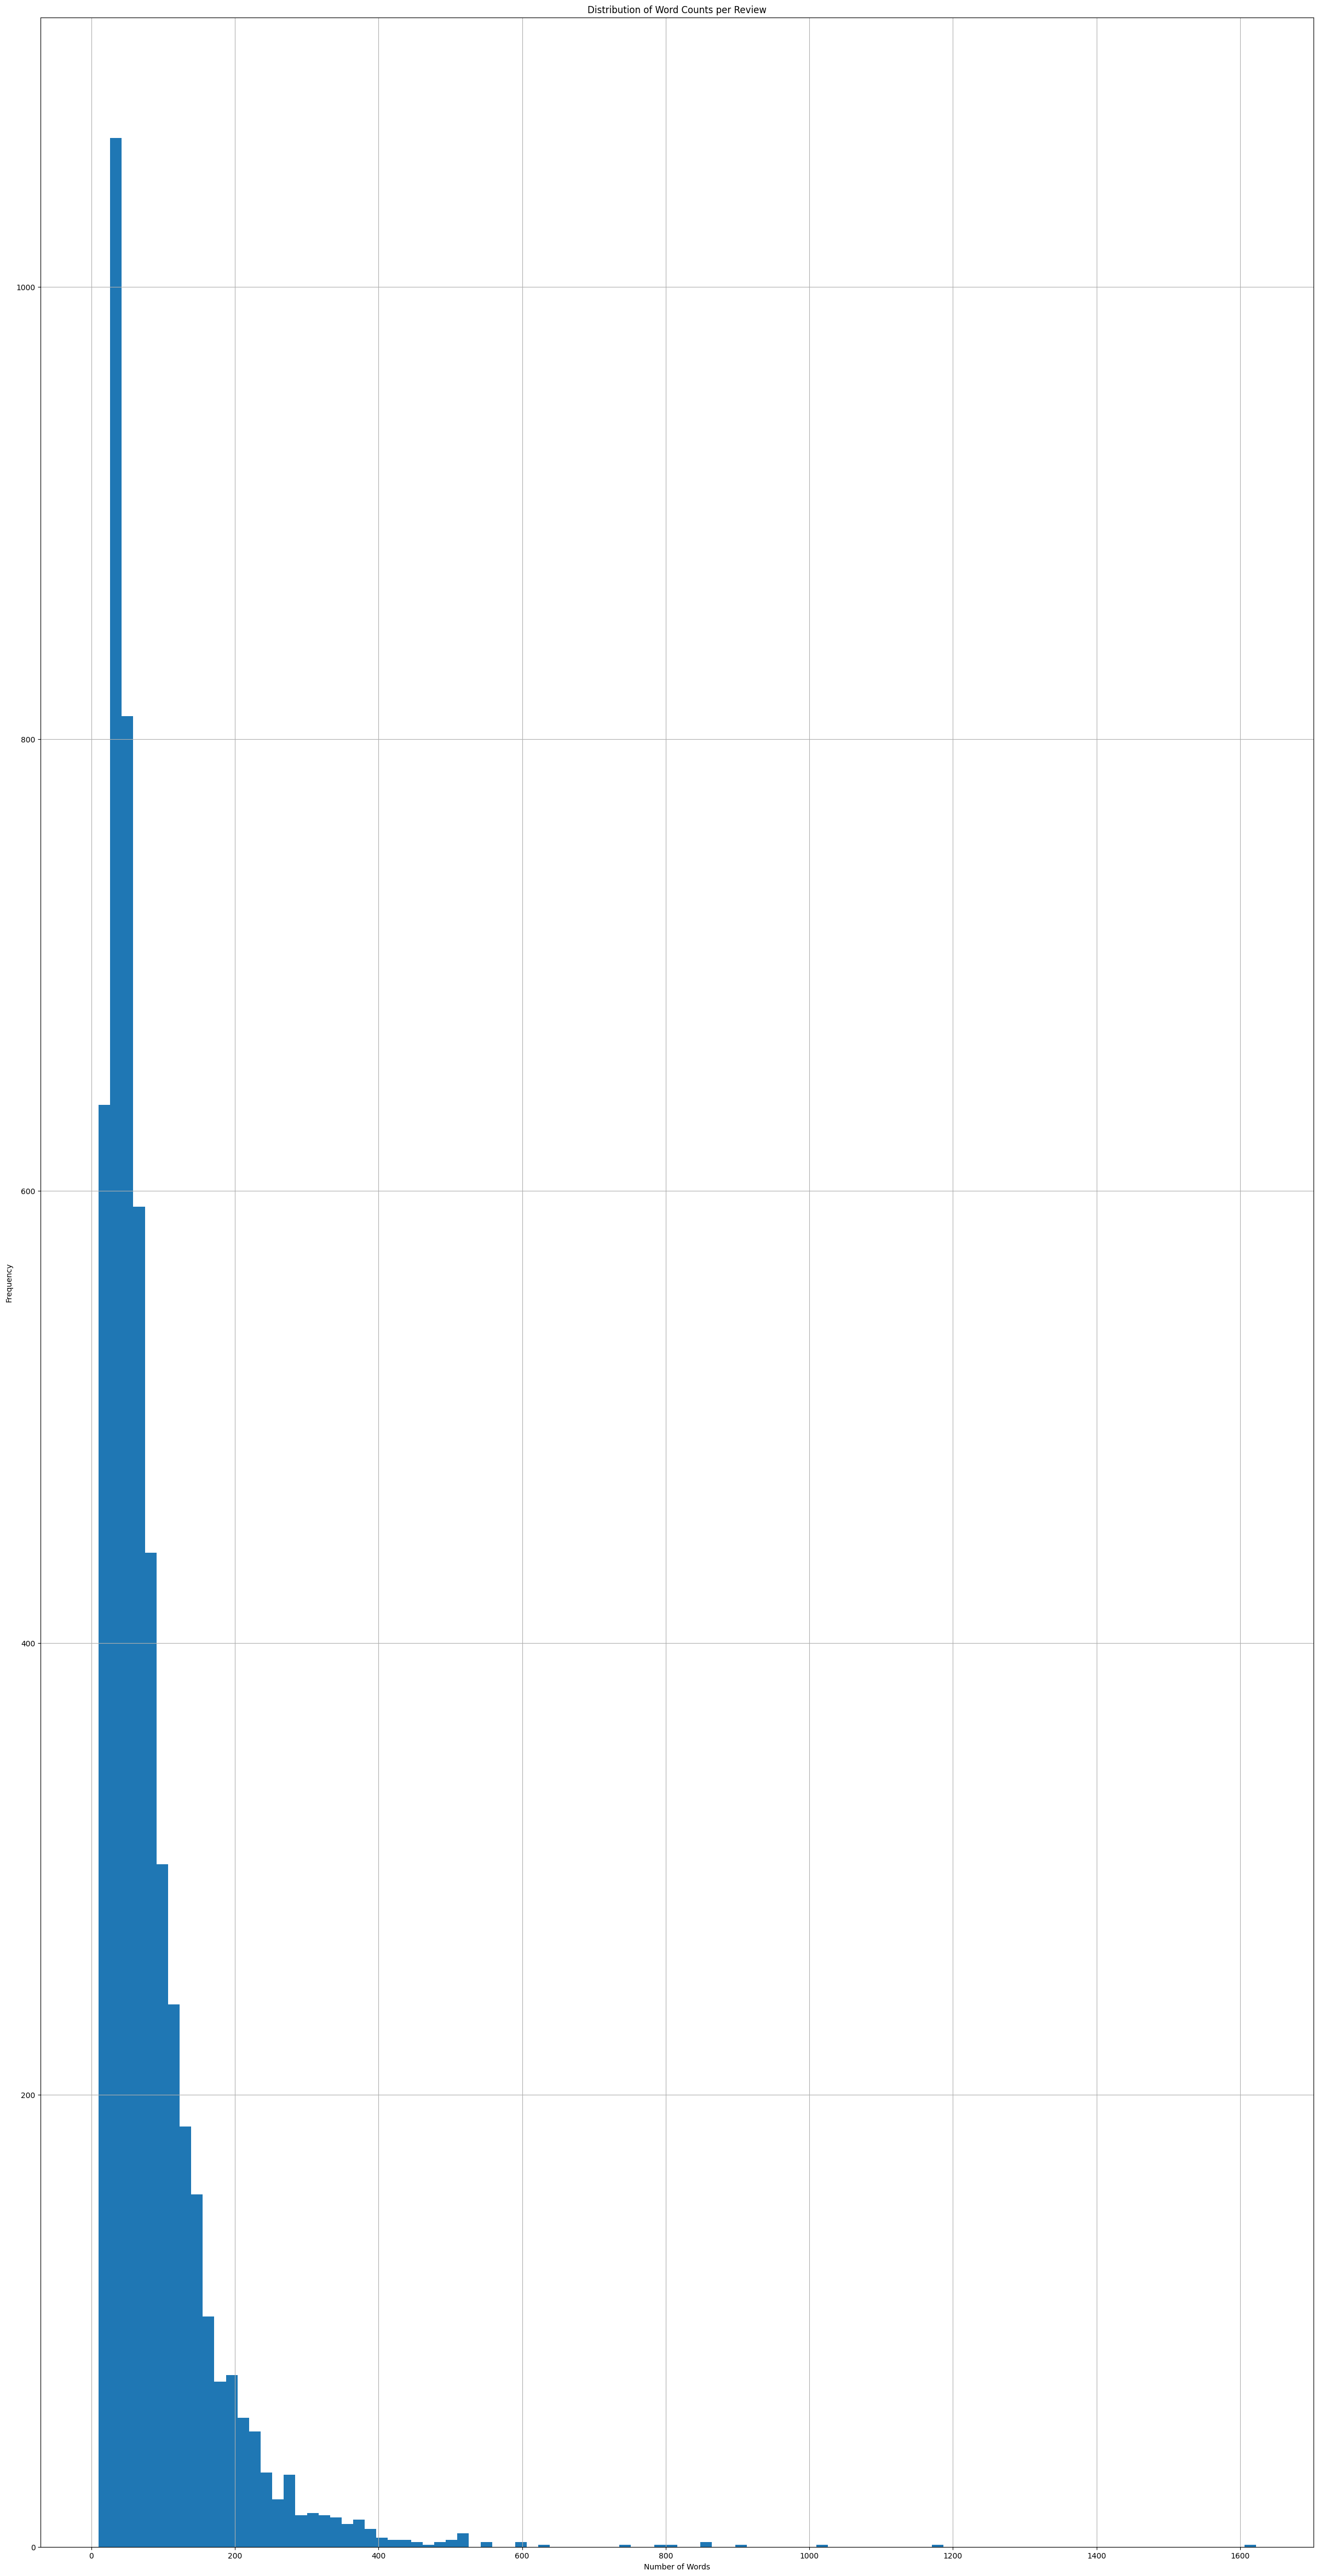

In [ ]:
# Calculate word count per review by splitting on spaces
words_per_review = amazon_reviews.Text.apply(lambda x: len(x.split(" ")))

# Plot histogram of words per review distribution
words_per_review.hist(bins=100)
plt.title('Distribution of Word Counts per Review')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

# Calculate and display mean word count
mean_word_count = words_per_review.mean()
print(f"Average words per review: {mean_word_count:.2f}")

In [ ]:
amazon_reviews.Score.value_counts()

,count
Score,
5,3161
4,739
1,454
3,389
2,257


<Axes: xlabel='Score'>

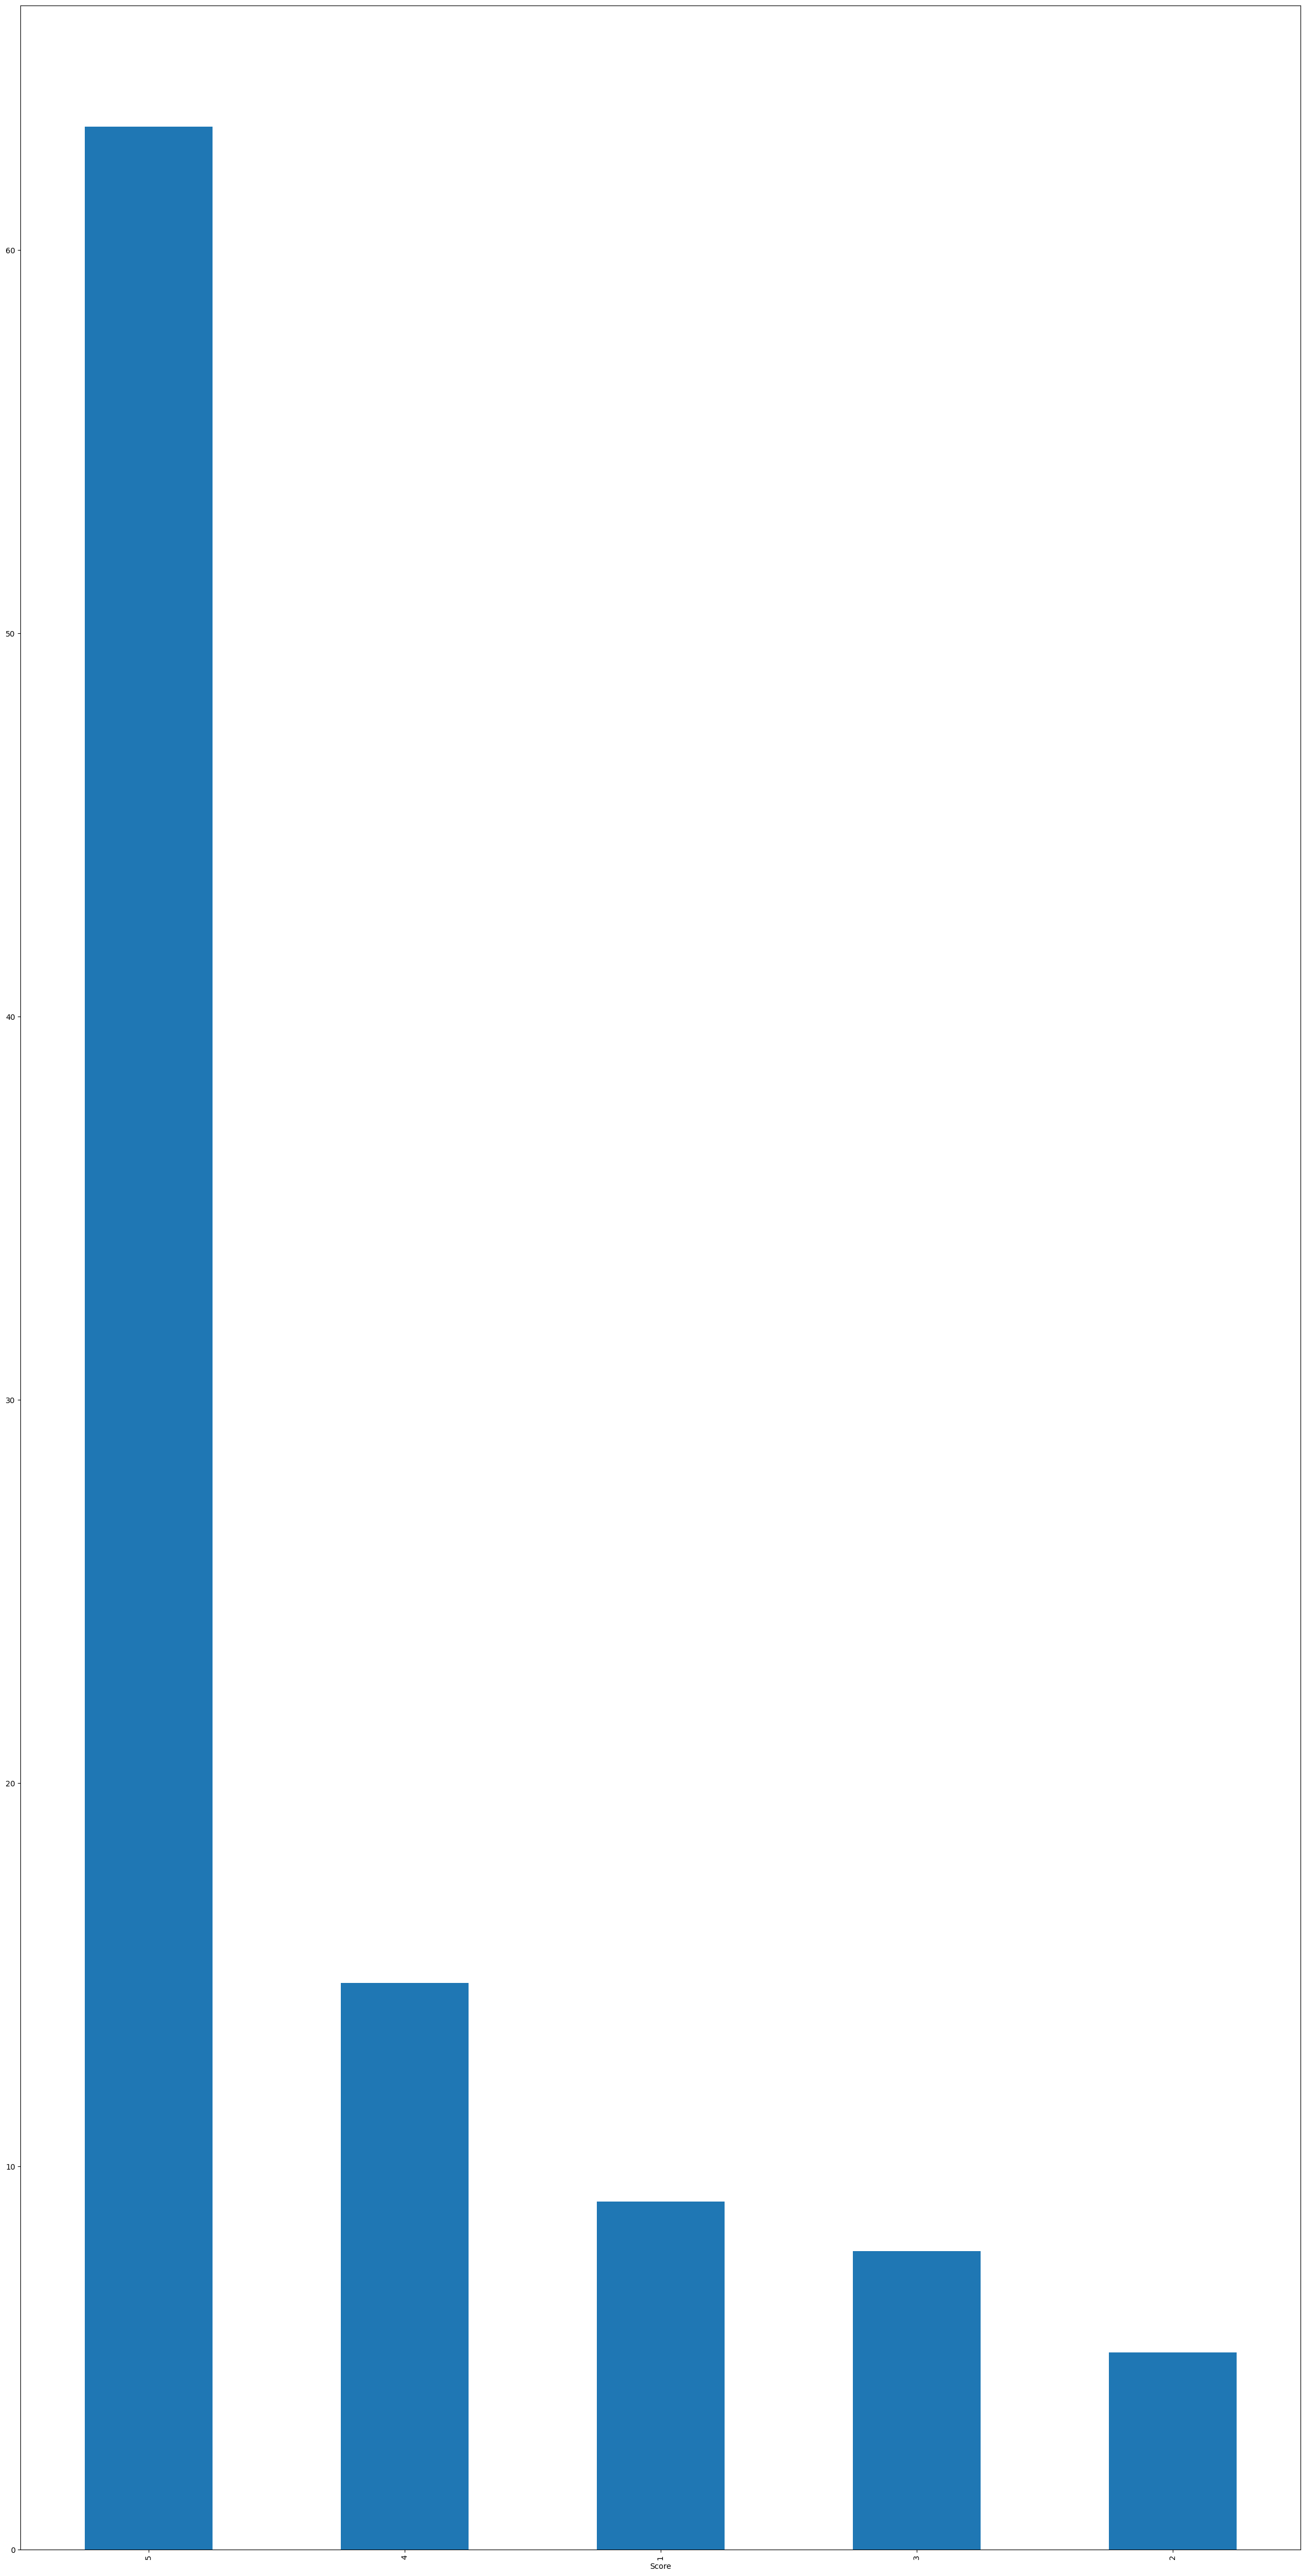

In [ ]:
percent_val = 100 * amazon_reviews.Score.value_counts()/amazon_reviews.shape[0]
percent_val.plot.bar()

##Excercise 1
Create a word cloud for the product reviews.

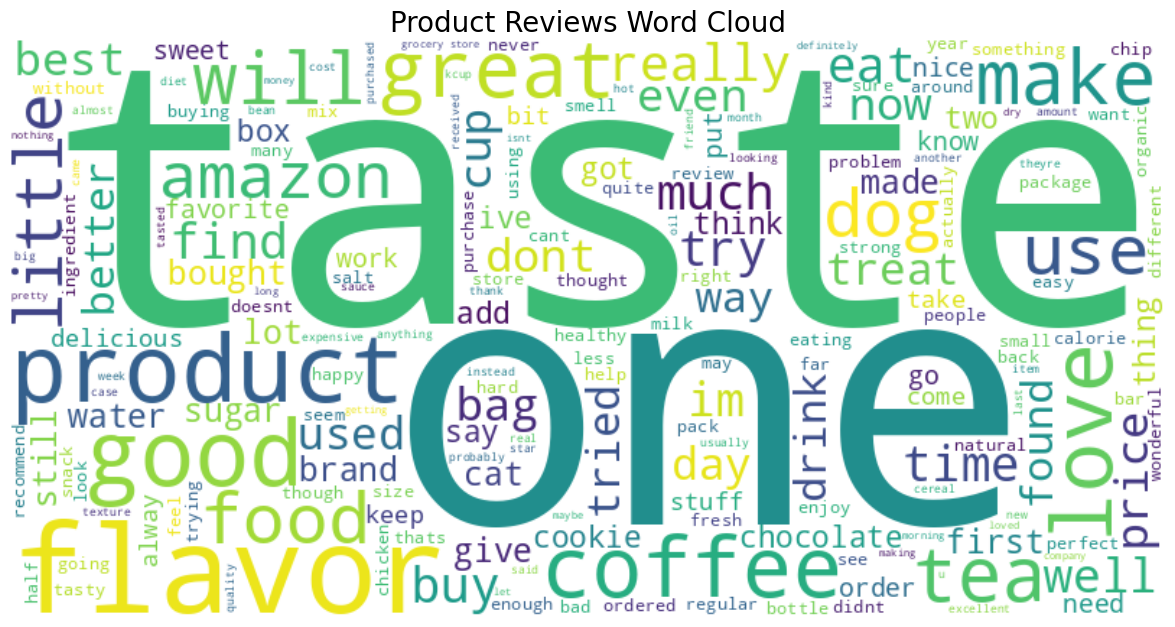

Palabras más frecuentes (top 50):

1. taste: 1.0000
2. one: 0.9115
3. flavor: 0.8299
4. product: 0.8282
5. good: 0.7730
6. love: 0.6540
7. coffee: 0.6511
8. great: 0.5885
9. make: 0.5224
10. tea: 0.5178
11. will: 0.4759
12. use: 0.4517
13. food: 0.4494
14. dog: 0.3862
15. little: 0.3822
16. amazon: 0.3724
17. really: 0.3724
18. much: 0.3586
19. eat: 0.3575
20. buy: 0.3477
21. find: 0.3443
22. time: 0.3391
23. try: 0.3391
24. im: 0.3276
25. well: 0.3241
26. cup: 0.3121
27. even: 0.3092
28. dont: 0.3080
29. bag: 0.3063
30. now: 0.3034
31. best: 0.3000
32. price: 0.2989
33. treat: 0.2845
34. used: 0.2770
35. day: 0.2770
36. tried: 0.2759
37. drink: 0.2592
38. better: 0.2586
39. way: 0.2575
40. found: 0.2534
41. bought: 0.2523
42. made: 0.2511
43. brand: 0.2443
44. cat: 0.2431
45. water: 0.2368
46. give: 0.2305
47. first: 0.2253
48. sugar: 0.2230
49. lot: 0.2224
50. still: 0.2195


In [ ]:
# Import required libraries for word cloud and text processing
from wordcloud import STOPWORDS
import re

# Combine all reviews into a single text string for processing
all_reviews = " ".join(review for review in amazon_reviews.Text.astype(str))

# Text cleaning pipeline:
# 1. Remove HTML tags (like <br>, <br />) using regex
cleaned_text = re.sub(r'<.*?>', ' ', all_reviews)  # Replace HTML tags with spaces

# 2. Remove non-alphabetic characters and numbers
cleaned_text = re.sub(r'[^A-Za-z\s]', '', cleaned_text)  # Keep only letters and whitespace

# 3. Convert all text to lowercase for consistent processing
cleaned_text = cleaned_text.lower()

# Generate word cloud with specified parameters:
# - Size: 800x400 pixels
# - Background: White
# - Max words: 200 most frequent
# - Stopwords: Common English words are automatically filtered
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=200,
    stopwords=STOPWORDS  # Uses default English stopwords
).generate(cleaned_text)

# Display the generated word cloud
plt.figure(figsize=(15, 7.5))  # Set large figure size for better visibility
plt.imshow(wordcloud, interpolation='bilinear')  # Smooth rendering
plt.axis("off")  # Remove axis markers
plt.title("Product Reviews Word Cloud", fontsize=20)  # Descriptive title
plt.show()

# Display top 50 most frequent words from the word cloud analysis
print("Most frequent words (top 50):\n")

# Iterate through the word frequency dictionary from the word cloud
# wordcloud.words_ contains word-frequency pairs sorted by frequency
for i, (word, freq) in enumerate(wordcloud.words_.items()):
    # Stop after displaying the top 50 words
    if i >= 50:
        break

    # Print formatted output showing:
    # 1. Rank (1-50)
    # 2. Word text
    # 3. Normalized frequency (4 decimal places)
    print(f"{i+1}. {word}: {freq:.4f}")

# Context

In [ ]:
amazon_reviews['Sentiment_rating'] = np.where(amazon_reviews.Score > 3, 1, 0)
amazon_reviews['Sentiment_rating'].value_counts()

,count
Sentiment_rating,
1,3900
0,1100


In [ ]:
# Removing neutral reviews
amazon_reviews = amazon_reviews[amazon_reviews.Score != 3]
amazon_reviews['Sentiment_rating'].value_counts()


,count
Sentiment_rating,
1,3900
0,711


<Axes: xlabel='Sentiment_rating'>

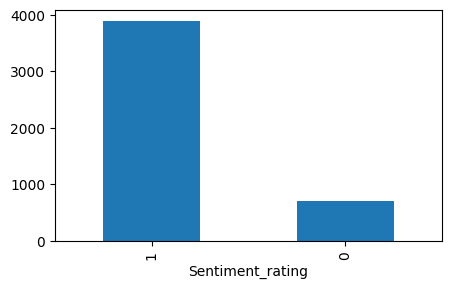

In [ ]:
rcParams['figure.figsize'] = 5, 3
amazon_reviews.Sentiment_rating.value_counts().plot.bar()


In [ ]:
amazon_reviews['reviews_text_new'] = amazon_reviews.Text.apply(lambda x: x.lower())

In [ ]:
nltk.download('punkt_tab')
token_lists = [word_tokenize(each) for each in amazon_reviews.Text]
tokens = [item for sublist in token_lists for item in sublist]
print("Number of unique tokens then: ", len(set(tokens)))
token_lists_lower = [word_tokenize(each) for each in amazon_reviews.reviews_text_new]
tokens_lower = [item for sublist in token_lists_lower for item in sublist]
print("Number of unique tokens now: ", len(set(tokens_lower)))


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Number of unique tokens then:  20598
Number of unique tokens now:  17083


## Exercise 2
Is removing special characters even a good idea? What are some examples of characters that would likely be safe to remove, and what are some that would not be?


**Answer**:Removing special characters can be useful for simplifying text and reducing noise, but it is not always a good idea to remove them entirely. Some characters, such as HTML tags (\<br>, \<div>) or symbols like @, #, and $, are generally safe to remove because they do not add meaningful value to the review content. However, other characters such as exclamation marks (!), question marks (?), apostrophes ('), hyphens (-), and even emojis can carry important emotional or contextual information. These elements often reflect the user's sentiment, tone, or grammar structure. Therefore, special characters should be removed selectively, based on whether they contribute meaning to the analysis or not.

# Contexto

In [ ]:
# Selecting non alpha numeric charactes that are not spaces
special_chars = amazon_reviews.reviews_text_new.apply(lambda x: [each for each in list(x) if not each.isalnum() and each  != ' '])
# Getting list of list into a single list
flat_list = [item for sublist in special_chars for item in sublist]
# Unique special characters
print(set(flat_list))


{"'", '(', '`', '/', '@', '<', '{', '!', ']', '\\', '$', ';', '~', '"', '}', '-', '=', '§', '%', ')', '>', '+', '*', ',', '_', '.', '?', ':', '[', '®', '#', '^', '|', '&'}


In [ ]:
review_backup = amazon_reviews.reviews_text_new.copy()
amazon_reviews.reviews_text_new = amazon_reviews.reviews_text_new.apply(
 lambda x: re.sub('[^A-Za-z0-9 ]+', ' ', x)
)
print("Old Review:")
review_backup.iloc[2]

Old Review:


"mccann's instant irish oatmeal, variety pack of regular, apples & cinnamon, and maple & brown sugar, 10-count boxes (pack of 6)<br /><br />i'm a fan of the mccann's steel-cut oats, so i thought i'd give the instant variety a try. i found it to be a hardy meal, not too sweet, and great for folks like me (post-bariatric surgery) who need food that is palatable, easily digestible, with fiber but won't make you bloat."

In [ ]:
print("New Review:")
amazon_reviews.reviews_text_new.iloc[2]

New Review:


'mccann s instant irish oatmeal  variety pack of regular  apples   cinnamon  and maple   brown sugar  10 count boxes  pack of 6 br  br  i m a fan of the mccann s steel cut oats  so i thought i d give the instant variety a try  i found it to be a hardy meal  not too sweet  and great for folks like me  post bariatric surgery  who need food that is palatable  easily digestible  with fiber but won t make you bloat '

In [ ]:
token_lists = [word_tokenize(each) for each in amazon_reviews.Text]
tokens = [item for sublist in token_lists for item in sublist]
print("Number of unique tokens then: ", len(set(tokens)))
token_lists = [word_tokenize(each) for each in amazon_reviews.reviews_text_new]
tokens = [item for sublist in token_lists for item in sublist]
print("Number of unique tokens now: ", len(set(tokens)))


Number of unique tokens then:  20598
Number of unique tokens now:  14315


In [ ]:
nltk.download('stopwords')
noise_words = []
stopwords_corpus = nltk.corpus.stopwords
eng_stop_words = stopwords_corpus.words('english')
noise_words.extend(eng_stop_words)
print(len(noise_words))
noise_words


198


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

## Exercise 3
Find the high- and low-frequency words, which we will define as the 1% of words that occur most often in the reviews, as well as define the 1% of words that occur  least often in the reviews (after adjusting for case and special characters). Ensure that, Stop words and high/low frequency words have now been added  to noise_words, which will be removed from the reviews prior to training machine learning models. At this point, print the total of resulting tokens.

In [ ]:
# Step 1: Extract all words from reviews (already tokenized and cleaned)
# Flatten the list of token lists into a single word list
all_words = [word for sublist in token_lists for word in sublist]

# Step 2: Calculate word frequencies using Counter
# Creates a dictionary of {word: frequency} pairs
word_freq = Counter(all_words)

# Step 3: Sort words by frequency (descending order)
# key=lambda x: x[1] sorts by the frequency count (second tuple element)
sorted_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

# Step 4: Identify top 1% most frequent words
total_words = len(sorted_words)
high_freq_count = int(total_words * 0.01)  # Calculate 1% threshold
high_freq_words = [word for word, freq in sorted_words[:high_freq_count]]  # Slice top 1%

# Step 5: Identify bottom 1% least frequent words
low_freq_count = int(total_words * 0.01)
low_freq_words = [word for word, freq in sorted_words[-low_freq_count:]]  # Slice last 1%

# Step 6: Add these words to noise_words list
noise_words.extend(high_freq_words)  # Add high-frequency stopwords
noise_words.extend(low_freq_words)  # Add low-frequency rare words

# Remove duplicates from noise_words using set conversion
noise_words = list(set(noise_words))

# Step 7: Filter tokens by removing noise words
# Only keep words not found in noise_words list
filtered_tokens = [word for word in all_words if word not in noise_words]

# Step 8: Display analysis results
print(f"Number of high-frequency words (top 1%): {len(high_freq_words)}")
print(f"Number of low-frequency words (bottom 1%): {len(low_freq_words)}")
print(f"Total words in noise_words list: {len(noise_words)}")
print(f"Remaining tokens after filtering: {len(filtered_tokens)}")

Number of high-frequency words (top 1%): 143
Number of low-frequency words (bottom 1%): 143
Total words in noise_words list: 404
Remaining tokens after filtering: 144748


# Contexto

In [ ]:
from nltk.stem import PorterStemmer, WordNetLemmatizer, LancasterStemmer
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import wordnet
porter = PorterStemmer()
lancaster = LancasterStemmer()
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
print("Lancaster Stemmer")
print(lancaster.stem("trouble"))
print(lancaster.stem("troubling"))
print(lancaster.stem("troubled"))
# Provide a word to be lemmatized
print("WordNet Lemmatizer")
print(lemmatizer.lemmatize("trouble", wordnet.NOUN))
print(lemmatizer.lemmatize("troubling", wordnet.VERB))
print(lemmatizer.lemmatize("troubled", wordnet.VERB))


Lancaster Stemmer
troubl
troubl
troubl
WordNet Lemmatizer
trouble
trouble
trouble


In [ ]:
amazon_reviews[['Text','Score','Sentiment_rating']].head(5)

,Text,Score,Sentiment_rating
0,Product arrived labeled as Jumbo Salted Peanut...,1,0
1,This is a good instant oatmeal from the best o...,4,1
2,"McCann's Instant Irish Oatmeal, Variety Pack o...",4,1
3,these are the best chips out there.. nothing c...,5,1
4,I knew my family already liked these chips so ...,5,1


In [ ]:
# Creating a method for stemming
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
analyzer = CountVectorizer().build_analyzer()
def stemmed_words(doc):
 return (stemmer.stem(w) for w in analyzer(doc))

 # Creating a python object of the class CountVectorizer
bow_counts = CountVectorizer(
 tokenizer=word_tokenize,
 stop_words=noise_words,
 ngram_range=(1, 1)
)

reviews_train, reviews_test = train_test_split(amazon_reviews, test_size=0.2, random_state=0)
X_train_bow = bow_counts.fit_transform(reviews_train.reviews_text_new)
X_test_bow = bow_counts.transform(reviews_test.reviews_text_new)

y_train_bow = reviews_train['Sentiment_rating']
y_test_bow = reviews_test['Sentiment_rating']
y_test_bow.value_counts() / y_test_bow.shape[0]


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'might', 'must', "n't", 'need', 'sha', 'wo'] not in stop_words.
  warnings.warn(


,count
Sentiment_rating,
1,0.84182
0,0.15818


In [ ]:
lr_model_all = LogisticRegression(C=1, solver="liblinear")
lr_model_all.fit(X_train_bow, y_train_bow)
# Predicting the output
test_pred_lr_prob = lr_model_all.predict_proba(X_test_bow)
test_pred_lr_all = lr_model_all.predict(X_test_bow)
print("F1 score: ", f1_score(y_test_bow, test_pred_lr_all))
print("Accuracy: ", accuracy_score(y_test_bow, test_pred_lr_all) * 100)

F1 score:  0.9329192546583851
Accuracy:  88.29902491874323


In [ ]:
probabilities = [each[1] for each in test_pred_lr_prob]
predictions = pd.DataFrame()
predictions['Text'] = reviews_test['Text']
predictions['Actual_Score'] = reviews_test['Score']
predictions['Sentiment_rating'] = reviews_test['Sentiment_rating']
predictions['Predicted_sentiment'] = test_pred_lr_all
predictions['Predicted_probability'] = probabilities
predictions.head(5)


,Text,Actual_Score,Sentiment_rating,Predicted_sentiment,Predicted_probability
2719,I honestly wish the other reviewer would have ...,5,1,1,0.999421
3602,Butterfinger hot chocolate is very good. It ta...,5,1,1,0.963817
409,These are so tasty and just the right amount o...,5,1,1,0.997077
3341,"Salsa Verde is my favorite Doritos flavor, but...",5,1,1,0.999849
3108,"As a Native American who is from Seattle, I wa...",1,0,0,0.030616


In [ ]:
accuracy_score(predictions['Sentiment_rating'], predictions['Predicted_sentiment'])

0.8829902491874323

In [ ]:
# Create a vectorizer - we still feed in our stop words, although
# these are less relevant now as TF-IDF would weight them less
# anyway.
tfidf_counts = TfidfVectorizer(
 tokenizer=word_tokenize,
 stop_words=noise_words,
 ngram_range=(1,1)
)
X_train_tfidf = tfidf_counts.fit_transform(reviews_train.reviews_text_new)
X_test_tfidf = tfidf_counts.transform(reviews_test.reviews_text_new)

# Create the classifier
lr_model_tf_idf = LogisticRegression(solver="liblinear")
# Train the classifier
lr_model_tf_idf.fit(X_train_tfidf, y_train_bow)
# Predict the results
test_pred_lr_prob = lr_model_tf_idf.predict_proba(X_test_tfidf)
test_pred_lr_all = lr_model_tf_idf.predict(X_test_tfidf)
## Evaluating the model
print("F1 score: ",f1_score(y_test_bow, test_pred_lr_all))
print("Accuracy: ", accuracy_score(y_test_bow, test_pred_lr_all) * 100)


/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'ll", "'m", "'re", "'s", "'ve", 'might', 'must', "n't", 'need', 'sha', 'wo'] not in stop_words.
  warnings.warn(


F1 score:  0.9183431952662722
Accuracy:  85.04875406283857


In [ ]:
!pip install gensim

In [ ]:
import gensim
# Loading a pre-trained glove word embedding that is trained on a Twitter dataset
# This word embedding is 200 dimensional, meaning that each word is represented
# by a 200 dimensional vector.
model = gensim.models.KeyedVectors.load_word2vec_format(
 os.path.join(os.getcwd(), '/content/drive/MyDrive/Anderson Fonseca López/2. Estudio/1. Ingeniería de sistemas y computación/2025 - 1/Big Data/Proyecto 2/glove.twitter.27B.200d_out.txt'),
 binary=False,
 unicode_errors='ignore'
)


In [ ]:
print("The embedding for food is", len(model['food']), "dimensional")
model['food']
print("The embedding for great is", len(model['great']), "dimensional")
model['great']

The embedding for food is 200 dimensional
The embedding for great is 200 dimensional


array([ 1.0751e-01,  1.5958e-01,  1.3332e-01,  1.6642e-01, -3.2737e-02,
        1.7592e-01,  7.2395e-01,  1.1713e-01, -3.5036e-01, -4.2937e-01,
       -4.0925e-01, -2.5761e-01, -1.0264e+00, -1.0014e-01,  5.5390e-02,
        2.0413e-01,  1.2807e-01, -2.6337e-02, -6.9719e-02, -3.6193e-02,
       -1.9917e-01,  3.9437e-02, -9.2358e-02,  2.6981e-01, -2.0951e-01,
        1.5455e+00, -2.8123e-01,  3.2046e-01,  4.5545e-01, -3.8841e-02,
       -1.7369e-01, -2.3251e-01, -5.9551e-02,  2.3250e-01,  4.4214e-01,
        3.3666e-01,  3.9352e-02, -1.2462e-01, -2.9317e-01, -4.8857e-02,
        6.9021e-01,  7.1279e-02,  1.0252e-01,  1.6122e-01, -2.3536e-01,
        6.2724e-02,  2.0222e-01,  5.0234e-02, -1.1611e-01,  2.8909e-02,
       -1.1109e-01, -5.0241e-02, -5.9063e-01, -8.8747e-02,  5.1444e-01,
       -1.3715e-01,  1.7194e-01, -8.3657e-02,  9.6333e-02, -9.7063e-02,
        3.4003e-03, -7.0180e-02, -5.9588e-01, -2.8264e-01,  1.2529e-01,
        2.4359e-01, -4.9082e-01, -4.2533e-02,  2.2158e-01, -2.14

In [ ]:
def print_similarity(word1, word2, model):
 v1 = model[word1]
 v2 = model[word2]
 similarity = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
 print(f"{word1} and {word2} are {round(similarity * 100)}% similar")
print_similarity("cat", "dog", model)
print_similarity("good", "bad", model)
print_similarity("great", "good", model)
print_similarity("grass", "model", model)

cat and dog are 83% similar
good and bad are 80% similar
great and good are 87% similar
grass and model are 11% similar


In [ ]:
# 1. Function to calculate average word embedding for a review
def get_review_embedding(review_text):
    # Tokenize text and convert to lowercase
    words = [word.lower() for word in word_tokenize(str(review_text)) if word.isalpha()]

    # Get vectors only for words present in the model
    word_vectors = [model[word] for word in words if word in model.key_to_index]

    if len(word_vectors) > 0:
        return np.mean(word_vectors, axis=0)  # Average of vectors
    else:
        return np.zeros(model.vector_size)  # Zero vector if no known words

# 2. Apply to all reviews (may take time)
print("Generating embeddings for reviews...")
review_embeddings = amazon_reviews['Text'].apply(get_review_embedding)

# 3. Convert to DataFrame
embedding_data = pd.DataFrame(list(review_embeddings))
embedding_data = embedding_data.fillna(0)

# Show data sample
print("\nEmbeddings sample:")
print(embedding_data.sample(10))

# 4. Split into training and test sets
X_train_embed, X_test_embed, y_train_embed, y_test_embed = train_test_split(
    embedding_data,
    amazon_reviews.Sentiment_rating,
    test_size=0.2,
    random_state=0
)

# 5. Train and evaluate model
print("\nTraining logistic regression model...")
lr_model = LogisticRegression(penalty="l1", C=10, solver="liblinear", max_iter=1000)
lr_model.fit(X_train_embed, y_train_embed)

# Predictions and evaluation
test_pred_lr_all = lr_model.predict(X_test_embed)
print("\nResults:")
print("F1 score: ", f1_score(y_test_embed, test_pred_lr_all))
print("Accuracy: ", accuracy_score(y_test_embed, test_pred_lr_all)*100)

Generating embeddings for reviews...

Embeddings sample:
           0         1         2         3         4         5         6    \
1740  0.021142  0.121886  0.021916  0.097161 -0.070333  0.115231  0.544041   
4537  0.028420  0.088191  0.123680  0.151827 -0.018745  0.137345  0.481319   
1552  0.043161  0.109506  0.095482  0.154796  0.000811  0.144369  0.508796   
4183 -0.008104  0.121861  0.066263  0.130250 -0.003903  0.184993  0.451627   
2064  0.039437  0.053064  0.060238  0.169891 -0.016436  0.089202  0.463571   
4347  0.028217  0.111048 -0.038415  0.096943 -0.042410  0.197663  0.531743   
1377  0.057110  0.146734  0.107485  0.096754 -0.166357  0.115915  0.600236   
2440 -0.011323  0.082161  0.042125  0.185934 -0.114505  0.131577  0.534871   
2362 -0.085542  0.008024 -0.016612  0.059637 -0.067266  0.089984  0.423841   
234   0.006419  0.041734  0.086852  0.161033 -0.051689  0.084848  0.481747   

           7         8         9    ...       190       191       192  \
1740 -0.118